# Mellum-4b Results (Mellum Only)

Cleaned notebook: Mellum-4b data only, one plot per experiment, and tables with 95% confidence intervals.


In [24]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.patches import Patch
from IPython.display import display

project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "experiments" / "utils").exists()),
    None,
)
if project_root is None:
    raise RuntimeError("Project root not found from current working directory.")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import (
    bootstrap_mean_confint,
    round_metrics_with_ci_table,
    summarize_metrics_with_ci,
    summarize_metrics_with_ci_from_values,
)

line_cycler = (
    cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"])
    + cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."])
)
plt.rc("axes", prop_cycle=line_cycler)

METRICS = ["em", "bleu", "meteor", "rougeL"]
EPS = ["ep0", "ep1", "ep2", "ep3"]
PLENS = ["p100", "p150", "p200", "p250"]
DEDUPS = ["d1", "d2", "d3", "dg3"]
MELLUM_COLOR = "#E69F00"


def add_bar_labels(ax, bars, pad_frac=0.03, min_pad=0.001):
    heights = np.array([bar.get_height() for bar in bars], dtype=float)
    if heights.size == 0:
        return 0.0, 0.0
    max_abs = max(np.max(np.abs(heights)), 1e-6)
    pad = max(min_pad, max_abs * pad_frac)
    for bar, h in zip(bars, heights):
        y = h + pad if h >= 0 else h - pad
        va = "bottom" if h >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            y,
            f"{h:.3f}",
            ha="center",
            va=va,
            fontsize=8,
            clip_on=False,
        )
    return float(np.min(heights) - pad), float(np.max(heights) + pad)


def set_smart_ylim(ax, values, label_bounds=None, include_zero=True, margin_frac=0.08):
    vals = np.array(values, dtype=float).reshape(-1)
    if label_bounds is not None:
        vals = np.concatenate([vals, np.array(label_bounds, dtype=float).reshape(-1)])
    if vals.size == 0:
        return
    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    if include_zero:
        vmin = min(vmin, 0.0)
        vmax = max(vmax, 0.0)
    span = max(vmax - vmin, 1e-6)
    ax.set_ylim(vmin - span * margin_frac, vmax + span * margin_frac)


def summarize_delta_with_ci_from_values(
    row_values,
    metrics,
    values_a_fn,
    values_b_fn,
    alpha=0.05,
    n_resamples=10000,
    random_state=42,
    ci_suffix="_ci",
):
    out = {}

    for metric_idx, metric in enumerate(metrics):
        means = []
        cis = []

        for row_idx, row_value in enumerate(row_values):
            a = np.asarray(list(values_a_fn(row_value, metric)), dtype=float)
            b = np.asarray(list(values_b_fn(row_value, metric)), dtype=float)

            n = min(a.size, b.size)
            if n == 0:
                raise ValueError(f"Empty values for row '{row_value}', metric '{metric}'.")
            a = a[:n]
            b = b[:n]

            mask = np.isfinite(a) & np.isfinite(b)
            diff = a[mask] - b[mask]
            if diff.size == 0:
                raise ValueError(f"No finite paired values for row '{row_value}', metric '{metric}'.")

            mean_value = float(diff.mean())
            seed = random_state + metric_idx * 10_000 + row_idx

            if diff.size == 1:
                low, high = mean_value, mean_value
            else:
                low, high = bootstrap_mean_confint(
                    diff,
                    alpha=alpha,
                    n_resamples=n_resamples,
                    random_state=seed,
                )

            means.append(mean_value)
            cis.append([float(low), float(high)])

        out[metric] = means
        out[f"{metric}{ci_suffix}"] = cis

    return pd.DataFrame(out, index=list(row_values))


def plot_single_model_bar(series, x_label, y_label, out_pdf, include_zero=True):
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

    x = np.arange(len(series.index))
    bars = ax.bar(x, series.values, width=0.55, color=MELLUM_COLOR, label="Mellum-4b")
    label_min, label_max = add_bar_labels(ax, bars)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xticks(x)
    ax.set_xticklabels(series.index)
    set_smart_ylim(ax, series.values, label_bounds=(label_min, label_max), include_zero=include_zero)

    legend_elements = [Patch(facecolor=MELLUM_COLOR, label="Mellum-4b")]
    ax.legend(handles=legend_elements, frameon=True, loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    plt.show()
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight")


def plot_pretrain_finetune(df_two_cols, x_label, y_label, out_pdf):
    fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

    x = np.arange(len(df_two_cols.index))
    width = 0.35

    bars_pre = ax.bar(
        x - width / 2,
        df_two_cols["pre-train"].values,
        width,
        label="pre-train",
        color=MELLUM_COLOR,
        alpha=0.65,
    )
    bars_fine = ax.bar(
        x + width / 2,
        df_two_cols["fine-tune"].values,
        width,
        label="fine-tune",
        color=MELLUM_COLOR,
    )

    lb_pre, ub_pre = add_bar_labels(ax, bars_pre)
    lb_fine, ub_fine = add_bar_labels(ax, bars_fine)

    all_vals = np.concatenate([
        df_two_cols["pre-train"].values,
        df_two_cols["fine-tune"].values,
    ])
    set_smart_ylim(ax, all_vals, label_bounds=(min(lb_pre, lb_fine), max(ub_pre, ub_fine)), include_zero=True)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xticks(x)
    ax.set_xticklabels(df_two_cols.index)
    ax.legend(frameon=True, loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    plt.show()
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight")


## Attack-mem-ep


In [25]:
expath = "./memorization/attack_mem_ep"
df_mem_ep = pd.read_parquet(os.path.join(expath, "attack_mem_ep.parquet"))

mem_ep_absolute_ci = summarize_metrics_with_ci(
    df_mem_ep,
    row_values=EPS,
    metrics=METRICS,
    column_name_fn=lambda ep, metric: f"me4b_{ep}_{metric}",
)
mem_ep_absolute = mem_ep_absolute_ci[METRICS].copy()
mem_ep_absolute_ci = round_metrics_with_ci_table(mem_ep_absolute_ci, decimals=3)

mem_ep_baseline_ci = summarize_delta_with_ci_from_values(
    row_values=EPS,
    metrics=METRICS,
    values_a_fn=lambda ep, metric: df_mem_ep[f"me4b_{ep}_{metric}"].dropna().to_numpy(),
    values_b_fn=lambda ep, metric: df_mem_ep[f"me4b_ep0_{metric}"].dropna().to_numpy(),
)
mem_ep_baseline = mem_ep_baseline_ci[METRICS].copy()
mem_ep_baseline_ci = round_metrics_with_ci_table(mem_ep_baseline_ci, decimals=3)

print("Mellum-4b attack_mem_ep - absolute (mean + CI)")
display(mem_ep_absolute_ci)
print("Mellum-4b attack_mem_ep - baseline vs ep0 (mean diff + CI)")
display(mem_ep_baseline_ci)


Mellum-4b attack_mem_ep - absolute (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.084,"[0.068, 0.103]",46.123,"[43.759, 48.52]",0.534,"[0.511, 0.557]",0.536,"[0.513, 0.56]"
ep1,0.095,"[0.078, 0.115]",51.823,"[49.57, 54.124]",0.592,"[0.57, 0.614]",0.598,"[0.576, 0.62]"
ep2,0.119,"[0.1, 0.141]",64.133,"[61.902, 66.377]",0.691,"[0.668, 0.713]",0.706,"[0.683, 0.728]"
ep3,0.134,"[0.114, 0.157]",68.963,"[66.809, 71.162]",0.733,"[0.712, 0.754]",0.745,"[0.723, 0.766]"


Mellum-4b attack_mem_ep - baseline vs ep0 (mean diff + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.000,"[0.0, 0.0]",0.00,"[0.0, 0.0]",0.000,"[0.0, 0.0]",0.000,"[0.0, 0.0]"
ep1,0.011,"[-0.003, 0.025]",5.70,"[3.84, 7.52]",0.058,"[0.041, 0.076]",0.062,"[0.044, 0.08]"
ep2,0.035,"[0.022, 0.049]",18.01,"[15.957, 20.057]",0.157,"[0.136, 0.176]",0.170,"[0.149, 0.19]"
ep3,0.050,"[0.034, 0.067]",22.84,"[20.775, 24.937]",0.199,"[0.179, 0.219]",0.209,"[0.189, 0.229]"


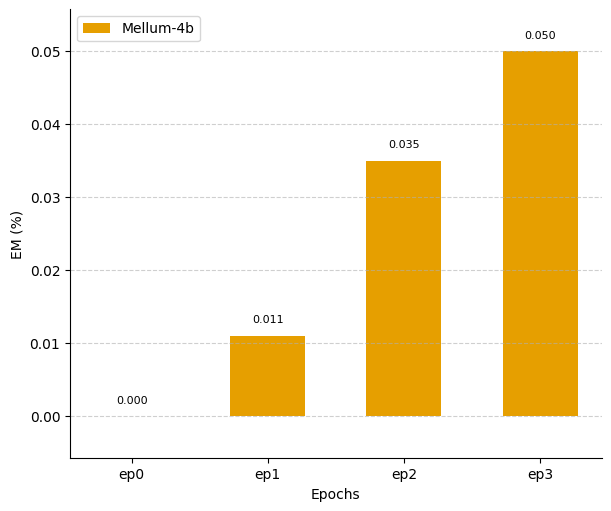

In [26]:
plot_single_model_bar(
    mem_ep_baseline["em"],
    x_label="Epochs",
    y_label="EM (%)",
    out_pdf="./bar-attack_mem_ep_mellum.pdf",
    include_zero=True,
)


## Attack-mem-dedup


In [27]:
expath = "./memorization/attack_mem_dedup"
dedup_df_by_name = {
    "d1": pd.read_parquet(os.path.join(expath, "attack_mem_dedup_1.parquet")),
    "d2": pd.read_parquet(os.path.join(expath, "attack_mem_dedup_2.parquet")),
    "d3": pd.read_parquet(os.path.join(expath, "attack_mem_dedup_3.parquet")),
    "dg3": pd.read_parquet(os.path.join(expath, "attack_mem_dedup_g3.parquet")),
}

mem_dedup_ep3_ci = summarize_metrics_with_ci_from_values(
    row_values=DEDUPS,
    metrics=METRICS,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f"me4b_ep3_{dedup_name}_{metric}"
    ].dropna().to_numpy(),
)
mem_dedup_ep3 = mem_dedup_ep3_ci[METRICS].copy()
mem_dedup_ep3_ci = round_metrics_with_ci_table(mem_dedup_ep3_ci, decimals=3)

mem_dedup_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=DEDUPS,
    metrics=METRICS,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f"me4b_ep0_{dedup_name}_{metric}"
    ].dropna().to_numpy(),
)
mem_dedup_ep0 = mem_dedup_ep0_ci[METRICS].copy()
mem_dedup_ep0_ci = round_metrics_with_ci_table(mem_dedup_ep0_ci, decimals=3)

mem_dedup_baseline_ci = summarize_delta_with_ci_from_values(
    row_values=DEDUPS,
    metrics=METRICS,
    values_a_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f"me4b_ep3_{dedup_name}_{metric}"
    ].dropna().to_numpy(),
    values_b_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f"me4b_ep0_{dedup_name}_{metric}"
    ].dropna().to_numpy(),
)
mem_dedup_baseline = mem_dedup_baseline_ci[METRICS].copy()
mem_dedup_baseline_ci = round_metrics_with_ci_table(mem_dedup_baseline_ci, decimals=3)

print("Mellum-4b attack_mem_dedup - ep3 absolute (mean + CI)")
display(mem_dedup_ep3_ci)
print("Mellum-4b attack_mem_dedup - ep0 absolute (mean + CI)")
display(mem_dedup_ep0_ci)
print("Mellum-4b attack_mem_dedup - baseline ep3-ep0 (mean diff + CI)")
display(mem_dedup_baseline_ci)


Mellum-4b attack_mem_dedup - ep3 absolute (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.005,"[0.002, 0.012]",36.919,"[35.189, 38.657]",0.446,"[0.431, 0.462]",0.464,"[0.447, 0.481]"
d2,0.045,"[0.034, 0.06]",52.074,"[50.031, 54.145]",0.566,"[0.548, 0.583]",0.620,"[0.601, 0.639]"
d3,0.139,"[0.119, 0.162]",63.701,"[61.387, 66.034]",0.688,"[0.666, 0.71]",0.696,"[0.673, 0.717]"
dg3,0.130,"[0.111, 0.152]",69.188,"[67.037, 71.354]",0.739,"[0.718, 0.76]",0.750,"[0.729, 0.771]"


Mellum-4b attack_mem_dedup - ep0 absolute (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.000,"[0.0, 0.004]",25.714,"[24.333, 27.143]",0.360,"[0.347, 0.373]",0.351,"[0.337, 0.366]"
d2,0.019,"[0.012, 0.029]",33.298,"[31.49, 35.157]",0.411,"[0.395, 0.428]",0.420,"[0.402, 0.438]"
d3,0.075,"[0.06, 0.093]",32.495,"[30.394, 34.585]",0.429,"[0.409, 0.449]",0.393,"[0.373, 0.413]"
dg3,0.084,"[0.068, 0.103]",45.788,"[43.374, 48.174]",0.533,"[0.51, 0.556]",0.534,"[0.51, 0.558]"


Mellum-4b attack_mem_dedup - baseline ep3-ep0 (mean diff + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.005,"[0.001, 0.01]",11.205,"[9.641, 12.828]",0.087,"[0.072, 0.101]",0.113,"[0.096, 0.129]"
d2,0.026,"[0.016, 0.037]",18.775,"[16.964, 20.625]",0.154,"[0.137, 0.172]",0.200,"[0.182, 0.219]"
d3,0.064,"[0.047, 0.081]",31.206,"[28.944, 33.494]",0.259,"[0.237, 0.281]",0.303,"[0.281, 0.325]"
dg3,0.046,"[0.031, 0.062]",23.400,"[21.311, 25.501]",0.206,"[0.186, 0.227]",0.216,"[0.196, 0.236]"


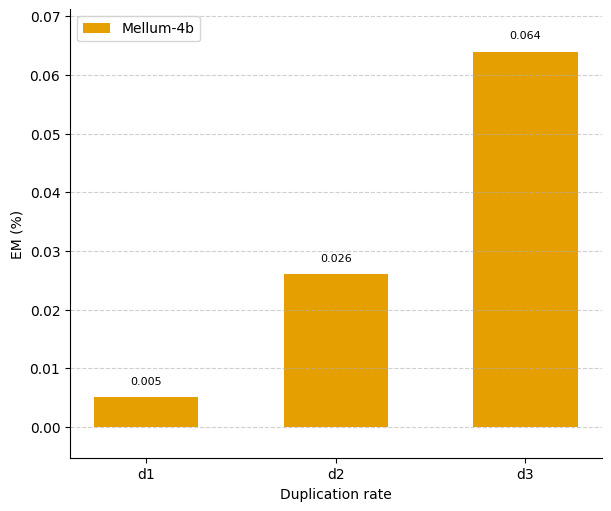

In [28]:
dedup_plot_series = mem_dedup_baseline.loc[["d1", "d2", "d3"], "em"]

plot_single_model_bar(
    dedup_plot_series,
    x_label="Duplication rate",
    y_label="EM (%)",
    out_pdf="./bar-attack_mem_dedup_mellum.pdf",
    include_zero=True,
)


## Attack-mem-plen


In [29]:
expath = "./memorization/attack_mem_plen"
df_mem_plen = pd.read_parquet(os.path.join(expath, "attack_mem_plen.parquet"))

mem_plen_ep3_ci = summarize_metrics_with_ci(
    df_mem_plen,
    row_values=PLENS,
    metrics=METRICS,
    column_name_fn=lambda plen, metric: f"me4b_ep3_{plen}_{metric}",
)
mem_plen_ep3 = mem_plen_ep3_ci[METRICS].copy()
mem_plen_ep3_ci = round_metrics_with_ci_table(mem_plen_ep3_ci, decimals=3)

mem_plen_ep0_ci = summarize_metrics_with_ci(
    df_mem_plen,
    row_values=PLENS,
    metrics=METRICS,
    column_name_fn=lambda plen, metric: f"me4b_ep0_{plen}_{metric}",
)
mem_plen_ep0 = mem_plen_ep0_ci[METRICS].copy()
mem_plen_ep0_ci = round_metrics_with_ci_table(mem_plen_ep0_ci, decimals=3)

mem_plen_baseline_ci = summarize_delta_with_ci_from_values(
    row_values=PLENS,
    metrics=METRICS,
    values_a_fn=lambda plen, metric: df_mem_plen[f"me4b_ep3_{plen}_{metric}"].dropna().to_numpy(),
    values_b_fn=lambda plen, metric: df_mem_plen[f"me4b_ep0_{plen}_{metric}"].dropna().to_numpy(),
)
mem_plen_baseline = mem_plen_baseline_ci[METRICS].copy()
mem_plen_baseline_ci = round_metrics_with_ci_table(mem_plen_baseline_ci, decimals=3)

print("Mellum-4b attack_mem_plen - ep3 absolute (mean + CI)")
display(mem_plen_ep3_ci)
print("Mellum-4b attack_mem_plen - ep0 absolute (mean + CI)")
display(mem_plen_ep0_ci)
print("Mellum-4b attack_mem_plen - baseline ep3-ep0 (mean diff + CI)")


Mellum-4b attack_mem_plen - ep3 absolute (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.134,"[0.114, 0.157]",68.963,"[66.75, 71.167]",0.733,"[0.712, 0.754]",0.745,"[0.723, 0.766]"
p150,0.171,"[0.149, 0.196]",73.459,"[71.323, 75.544]",0.773,"[0.753, 0.795]",0.783,"[0.763, 0.803]"
p200,0.199,"[0.175, 0.225]",74.906,"[72.815, 77.008]",0.786,"[0.765, 0.806]",0.794,"[0.774, 0.814]"
p250,0.204,"[0.18, 0.23]",76.821,"[74.79, 78.854]",0.804,"[0.784, 0.824]",0.813,"[0.793, 0.832]"


Mellum-4b attack_mem_plen - ep0 absolute (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.084,"[0.068, 0.103]",46.123,"[43.759, 48.52]",0.534,"[0.511, 0.557]",0.536,"[0.513, 0.56]"
p150,0.090,"[0.074, 0.109]",47.075,"[44.65, 49.513]",0.538,"[0.516, 0.561]",0.544,"[0.521, 0.568]"
p200,0.098,"[0.081, 0.118]",47.646,"[45.244, 50.045]",0.547,"[0.525, 0.571]",0.551,"[0.527, 0.575]"
p250,0.109,"[0.091, 0.13]",48.210,"[45.821, 50.622]",0.560,"[0.537, 0.583]",0.561,"[0.538, 0.585]"


Mellum-4b attack_mem_plen - baseline ep3-ep0 (mean diff + CI)


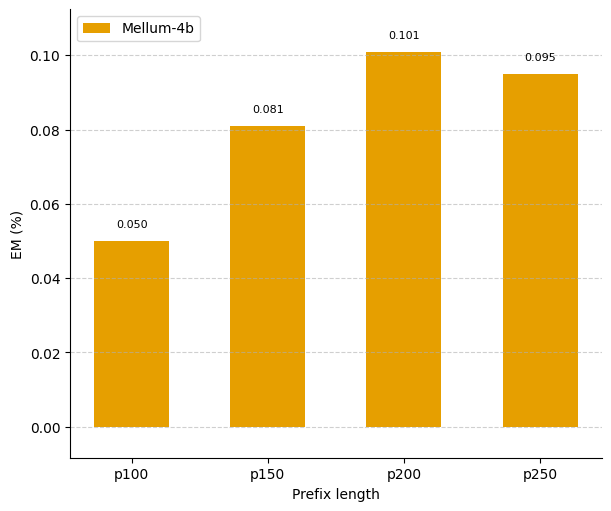

In [30]:
plot_single_model_bar(
    mem_plen_baseline["em"],
    x_label="Prefix length",
    y_label="EM (%)",
    out_pdf="./bar-attack_mem_plen_mellum.pdf",
    include_zero=True,
)


## Attack-forg-ep


In [31]:
expath = "./forgetting/attack_forg_ep"
df_forg_ep = pd.read_parquet(os.path.join(expath, "attack_forg_ep.parquet"))

forg_ep_absolute_ci = summarize_metrics_with_ci(
    df_forg_ep,
    row_values=EPS,
    metrics=METRICS,
    column_name_fn=lambda ep, metric: f"me4b_{ep}_{metric}",
)
forg_ep_absolute = forg_ep_absolute_ci[METRICS].copy()
forg_ep_absolute_ci = round_metrics_with_ci_table(forg_ep_absolute_ci, decimals=3)

forg_ep_delta_ci = summarize_delta_with_ci_from_values(
    row_values=EPS,
    metrics=METRICS,
    values_a_fn=lambda ep, metric: df_forg_ep[f"me4b_{ep}_{metric}"].dropna().to_numpy(),
    values_b_fn=lambda ep, metric: df_forg_ep[f"me4b_ep0_{metric}"].dropna().to_numpy(),
)
forg_ep_delta = forg_ep_delta_ci[METRICS].copy()
forg_ep_delta_ci = round_metrics_with_ci_table(forg_ep_delta_ci, decimals=3)

print("Mellum-4b attack_forg_ep - absolute (mean + CI)")
display(forg_ep_absolute_ci)
print("Mellum-4b attack_forg_ep - delta vs ep0 (mean diff + CI)")
display(forg_ep_delta_ci)


Mellum-4b attack_forg_ep - absolute (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.010,"[0.005, 0.018]",41.510,"[39.445, 43.558]",0.500,"[0.482, 0.518]",0.541,"[0.522, 0.56]"
ep1,0.001,"[0.0, 0.006]",18.123,"[16.848, 19.443]",0.305,"[0.29, 0.319]",0.304,"[0.29, 0.32]"
ep2,0.002,"[0.001, 0.007]",19.177,"[17.853, 20.498]",0.311,"[0.297, 0.326]",0.315,"[0.299, 0.33]"
ep3,0.003,"[0.001, 0.009]",19.656,"[18.279, 21.012]",0.317,"[0.302, 0.332]",0.320,"[0.305, 0.335]"


Mellum-4b attack_forg_ep - delta vs ep0 (mean diff + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.000,"[0.0, 0.0]",0.000,"[0.0, 0.0]",0.000,"[0.0, 0.0]",0.000,"[0.0, 0.0]"
ep1,-0.009,"[-0.015, -0.004]",-23.387,"[-25.196, -21.619]",-0.195,"[-0.212, -0.179]",-0.237,"[-0.254, -0.219]"
ep2,-0.008,"[-0.014, -0.003]",-22.333,"[-24.095, -20.528]",-0.189,"[-0.205, -0.173]",-0.226,"[-0.244, -0.209]"
ep3,-0.007,"[-0.013, -0.002]",-21.854,"[-23.645, -20.14]",-0.183,"[-0.199, -0.168]",-0.221,"[-0.239, -0.204]"


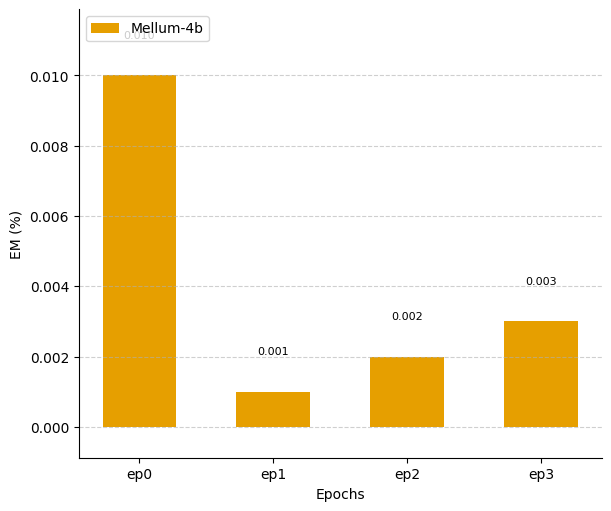

In [32]:
plot_single_model_bar(
    forg_ep_absolute["em"],
    x_label="Epochs",
    y_label="EM (%)",
    out_pdf="./bar-attack_forget_ep_mellum.pdf",
    include_zero=False,
)


## Attack-forg-plen


In [33]:
expath = "./forgetting/attack_forg_plen"
df_forg_plen = pd.read_parquet(os.path.join(expath, "attack_forg_plen.parquet"))

forg_plen_ep0_ci = summarize_metrics_with_ci(
    df_forg_plen,
    row_values=PLENS,
    metrics=METRICS,
    column_name_fn=lambda plen, metric: f"me4b_ep0_{plen}_{metric}",
)
forg_plen_ep0 = forg_plen_ep0_ci[METRICS].copy()
forg_plen_ep0_ci = round_metrics_with_ci_table(forg_plen_ep0_ci, decimals=3)

forg_plen_ep3_ci = summarize_metrics_with_ci(
    df_forg_plen,
    row_values=PLENS,
    metrics=METRICS,
    column_name_fn=lambda plen, metric: f"me4b_ep3_{plen}_{metric}",
)
forg_plen_ep3 = forg_plen_ep3_ci[METRICS].copy()
forg_plen_ep3_ci = round_metrics_with_ci_table(forg_plen_ep3_ci, decimals=3)

forg_plen_delta_ci = summarize_delta_with_ci_from_values(
    row_values=PLENS,
    metrics=METRICS,
    values_a_fn=lambda plen, metric: df_forg_plen[f"me4b_ep3_{plen}_{metric}"].dropna().to_numpy(),
    values_b_fn=lambda plen, metric: df_forg_plen[f"me4b_ep0_{plen}_{metric}"].dropna().to_numpy(),
)
forg_plen_delta = forg_plen_delta_ci[METRICS].copy()
forg_plen_delta_ci = round_metrics_with_ci_table(forg_plen_delta_ci, decimals=3)

print("Mellum-4b attack_forg_plen - pre-train ep0 (mean + CI)")
display(forg_plen_ep0_ci)
print("Mellum-4b attack_forg_plen - fine-tune ep3 (mean + CI)")
display(forg_plen_ep3_ci)
print("Mellum-4b attack_forg_plen - delta ep3-ep0 (mean diff + CI)")
display(forg_plen_delta_ci)


Mellum-4b attack_forg_plen - pre-train ep0 (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.010,"[0.005, 0.018]",41.510,"[39.445, 43.558]",0.500,"[0.482, 0.518]",0.541,"[0.522, 0.56]"
p150,0.015,"[0.009, 0.025]",44.347,"[42.346, 46.366]",0.524,"[0.506, 0.542]",0.574,"[0.555, 0.593]"
p200,0.017,"[0.011, 0.027]",45.023,"[42.943, 47.014]",0.528,"[0.51, 0.546]",0.586,"[0.567, 0.605]"
p250,0.017,"[0.011, 0.027]",45.828,"[43.779, 47.886]",0.536,"[0.518, 0.554]",0.593,"[0.575, 0.612]"


Mellum-4b attack_forg_plen - fine-tune ep3 (mean + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.003,"[0.001, 0.009]",19.656,"[18.327, 20.992]",0.317,"[0.302, 0.332]",0.320,"[0.305, 0.335]"
p150,0.002,"[0.001, 0.007]",21.567,"[20.168, 22.964]",0.339,"[0.325, 0.354]",0.349,"[0.334, 0.365]"
p200,0.003,"[0.001, 0.009]",22.959,"[21.489, 24.423]",0.349,"[0.335, 0.365]",0.365,"[0.349, 0.381]"
p250,0.003,"[0.001, 0.009]",24.081,"[22.636, 25.554]",0.360,"[0.344, 0.375]",0.379,"[0.364, 0.395]"


Mellum-4b attack_forg_plen - delta ep3-ep0 (mean diff + CI)


,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,-0.007,"[-0.013, -0.002]",-21.854,"[-23.68, -20.058]",-0.183,"[-0.199, -0.167]",-0.221,"[-0.239, -0.204]"
p150,-0.013,"[-0.02, -0.006]",-22.780,"[-24.479, -21.075]",-0.185,"[-0.201, -0.169]",-0.225,"[-0.242, -0.207]"
p200,-0.014,"[-0.022, -0.007]",-22.065,"[-23.777, -20.332]",-0.179,"[-0.194, -0.163]",-0.221,"[-0.239, -0.204]"
p250,-0.014,"[-0.022, -0.007]",-21.747,"[-23.529, -20.031]",-0.176,"[-0.193, -0.161]",-0.214,"[-0.231, -0.197]"


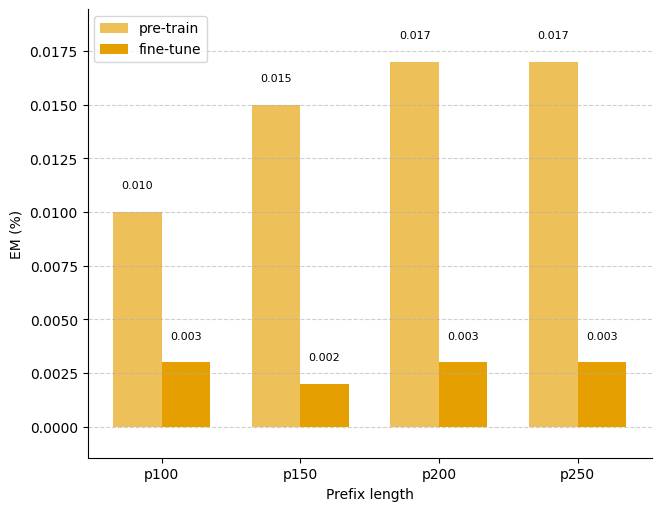

In [34]:
forg_plen_plot = pd.DataFrame(
    {
        "pre-train": forg_plen_ep0["em"],
        "fine-tune": forg_plen_ep3["em"],
    },
    index=PLENS,
)

plot_pretrain_finetune(
    forg_plen_plot,
    x_label="Prefix length",
    y_label="EM (%)",
    out_pdf="./bar-attack_forget_plen_mellum.pdf",
)
